<div style="
    font-family: 'Poppins', sans-serif;
    background-color: #003366;
    color: white;
    width: 700px;
    padding: 50px;
    border-radius: 25px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
">
    <h1 style="font-size: 42px; margin-bottom: 25px;">Jose Carlos Fernandez</h1>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Matrícula:</strong> 2024-0371</p>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Fecha:</strong> 11/06/2025</p>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Maestro:</strong> Esloboan Alberto Mora</p>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Practica:</strong> Primer Parcial</p>

</div>

# **Parte 1: Exploración de Datos (2 puntos)**

**Importacion de librerias**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import poisson

**Importacion de los datos**

In [4]:
# Creamos una ruta absoluta al archivo Excel
ruta = r"D:\OneDrive - Instituto Tecnológico de Las Américas (ITLA)\Estudio de Caso.  Primer parcial Descriptiva III.xlsx"

# Cargamos el archivo Excel a un DataFrame de pandas
data = pd.read_excel(ruta)

# Mostramos las primeras filas del DataFrame para verificar que se ha cargado correctamente
data.head()

,Día,Pedidos_diarios,Tiempo_promedio_entrega (min)
0,1,23,39.5
1,2,15,32.7
2,3,21,33.0
3,4,25,31.7
4,5,15,24.3


### **1.	Realiza una tabla de frecuencias para la variable Pedidos diarios. (0.3 punto)**

In [5]:
# Tabla de frecuencias para la variable "Pedidos diarios"
tabla_frecuencias = data['Pedidos_diarios'].value_counts().sort_index().reset_index()
tabla_frecuencias.columns = ['Pedidos_diarios', 'Frecuencia']

tabla_frecuencias

# Esto mostrara cuántas veces aparece cada valor de "Pedidos_diarios" en mi DataFrame

,Pedidos_diarios,Frecuencia
0,13,1
1,14,3
2,15,2
3,16,3
4,17,10
5,18,3
6,19,4
7,20,1
8,21,6
9,22,1


### **2.	Calcula media, mediana, moda y desviación estándar para ambas variables. (0.3 punto)** 

In [6]:
# Media
media_pedidos = data['Pedidos_diarios'].mean()
media_tiempo = data['Tiempo_promedio_entrega (min)'].mean()

# Mediana
mediana_pedidos = data['Pedidos_diarios'].median()
mediana_tiempo = data['Tiempo_promedio_entrega (min)'].median()

# Moda
moda_pedidos = data['Pedidos_diarios'].mode()[0]
moda_tiempo = data['Tiempo_promedio_entrega (min)'].mode()[0]

# Desviación estándar
std_pedidos = data['Pedidos_diarios'].std()
std_tiempo = data['Tiempo_promedio_entrega (min)'].std()

In [7]:
# Los Resultados son:
print("Pedidos diarios - Media:", media_pedidos)
print("Pedidos diarios - Mediana:", mediana_pedidos)
print("Pedidos diarios - Moda:", moda_pedidos)
print("Pedidos diarios - Desviación estándar:", std_pedidos)
print()
print("Tiempo de entrega - Media:", media_tiempo)
print("Tiempo de entrega - Mediana:", mediana_tiempo)
print("Tiempo de entrega - Moda:", moda_tiempo)
print("Tiempo de entrega - Desviación estándar:", std_tiempo)

Pedidos diarios - Media: 20.06
Pedidos diarios - Mediana: 19.0
Pedidos diarios - Moda: 17
Pedidos diarios - Desviación estándar: 4.147337478824856

Tiempo de entrega - Media: 32.04
Tiempo de entrega - Mediana: 32.55
Tiempo de entrega - Moda: 33.0
Tiempo de entrega - Desviación estándar: 3.9908568973981273


### **3.	Describe si existe alguna relación visible entre el número de pedidos y el tiempo de entrega. (0.3 punto)**

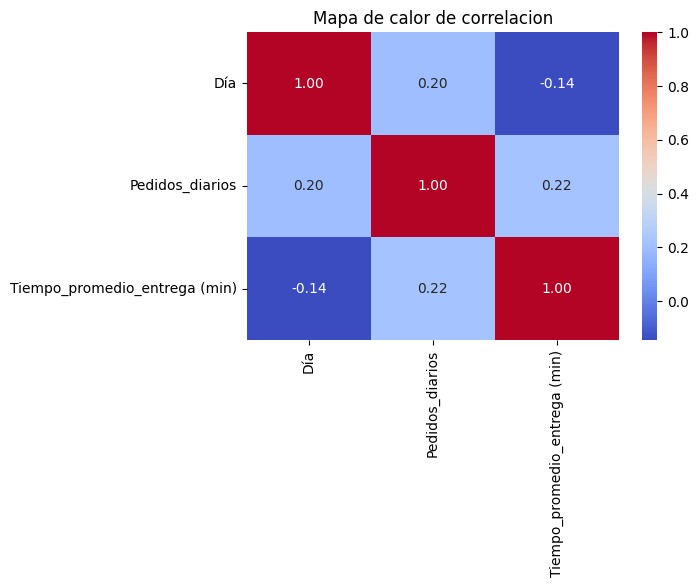

In [8]:
# Creamos una variable que almacene la correlación entre las variables numéricas del DataFrame
corr = data.corr(numeric_only=True)

# Crea el mapa de calor
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor de correlacion')
plt.show()

# Con este mapa de calor, vamos a poder observar la relación entre las variables numéricas del DataFrame y opinar sobre eso, porque esa es la peticion.

- **Aqui se puede ver como la variable `pedidos_diarios` tiene un coeficiente de relacion de un `0.22` con la variable `tiempo promedio de entrega`.**
- **Tomando en cuenta el valor del coeficiente, yo digo que es una relacion `muy debil`, ya que basicamente es un `22% relacionable`... en comparacion a 100%, es muy bajo**

### **4.	Crea cuatro gráficos:**
 - Histograma para la variable Pedidos diarios (0.3 punto)
 - Gráfico de dispersión entre Pedidos diarios y Tiempo promedio entrega (0.3 punto)
 - Gráfico de una distribución normal. (0.3 punto)
 - Gráfico de distribución acumulada. (0.3 punto)


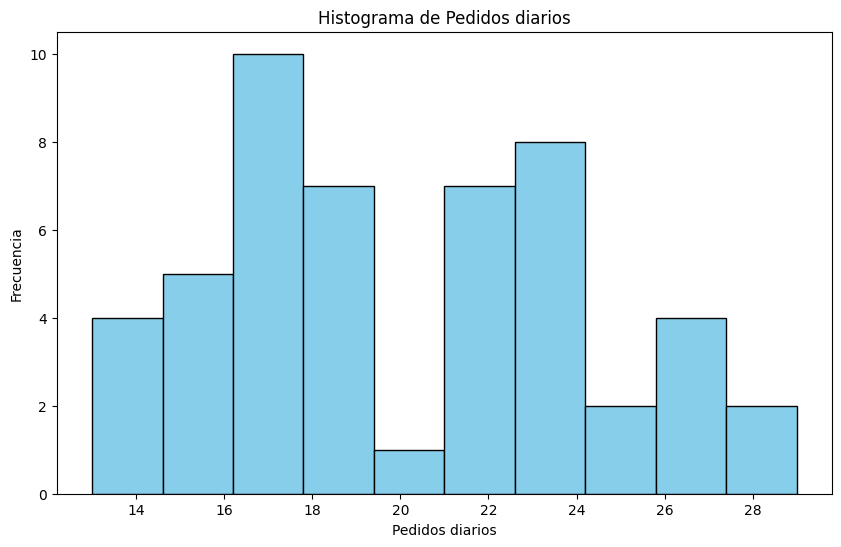

In [9]:
# 1. Histograma para Pedidos diarios
plt.figure(figsize=(10,6))
plt.hist(data['Pedidos_diarios'], color='skyblue', edgecolor='black')
plt.title('Histograma de Pedidos diarios')
plt.xlabel('Pedidos diarios')
plt.ylabel('Frecuencia')
plt.show()

**Que se observa?**

- La mayoría de los días, los pedidos diarios están entre 16 y 24.

- Hay pocos días con valores muy bajos (13-14) o muy altos (27-29).

- La distribución parece estar algo concentrada en el centro, pero con cierta dispersión hacia ambos lados.

---

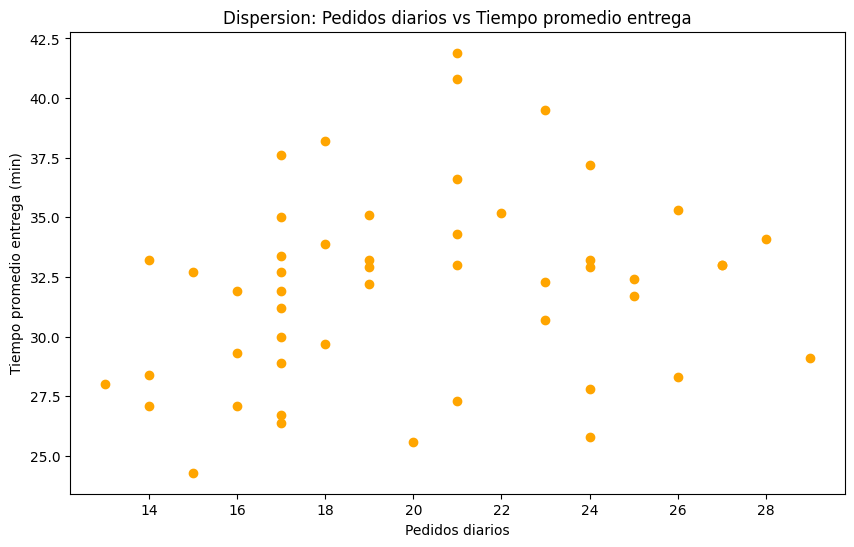

In [10]:
# 2. Grafico de dispersion entre Pedidos diarios y Tiempo promedio entrega
plt.figure(figsize=(10,6))
plt.scatter(data['Pedidos_diarios'], data['Tiempo_promedio_entrega (min)'], color='orange')
plt.title('Dispersion: Pedidos diarios vs Tiempo promedio entrega')
plt.xlabel('Pedidos diarios')
plt.ylabel('Tiempo promedio entrega (min)')
plt.show()

**Cada punto representa un día con su cantidad de pedidos y el tiempo promedio de entrega correspondiente.**

**Este tipo de gráfico es el adecuado para visualizar si existe alguna relación o tendencia entre ambas variables.**

**En mi caso, los puntos parecen dispersos y no muestran una tendencia clara, lo que coincide con la correlacion baja que he calculado (0.22).**

---

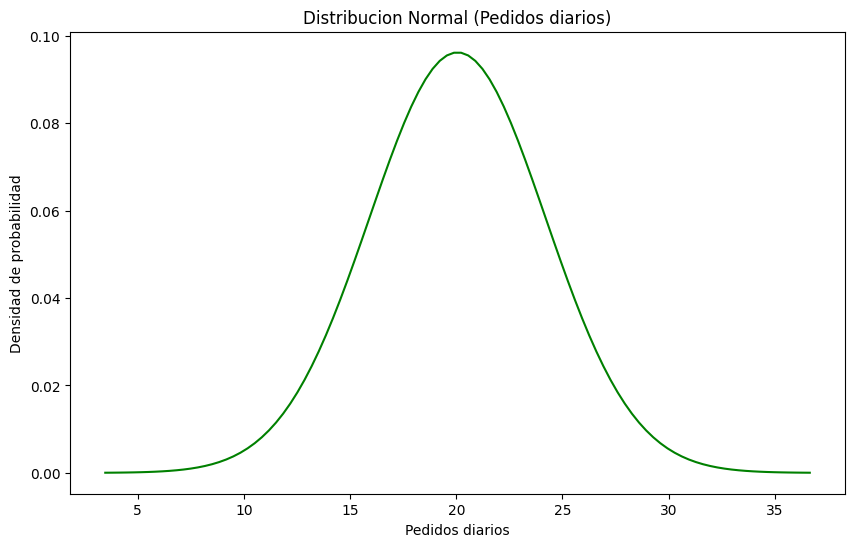

In [11]:
# 3. Grafico de una distribucion normal (usando la media y desviacion estandar de Pedidos diarios)

x = np.linspace(media_pedidos - 4*std_pedidos, media_pedidos + 4*std_pedidos, 100)

plt.figure(figsize=(10,6))
plt.plot(x, norm.pdf(x, media_pedidos, std_pedidos), color='green') # .pdf es la funcion de densidad de probabilidad
plt.title('Distribucion Normal (Pedidos diarios)')
plt.xlabel('Pedidos diarios')
plt.ylabel('Densidad de probabilidad')
plt.show()


**El `4` que multiplica la desviacion estandar se usa para crear un rango de valores que va desde 4 desviaciones estándar por debajo de la media hasta 4 desviaciones estándar por encima de la media.**

**Esto abarca prácticamente toda la distribución normal (más del 99.99% de los datos), asegurando que el gráfico muestre toda la "campana" de la normal, incluso los valores extremos.**

---

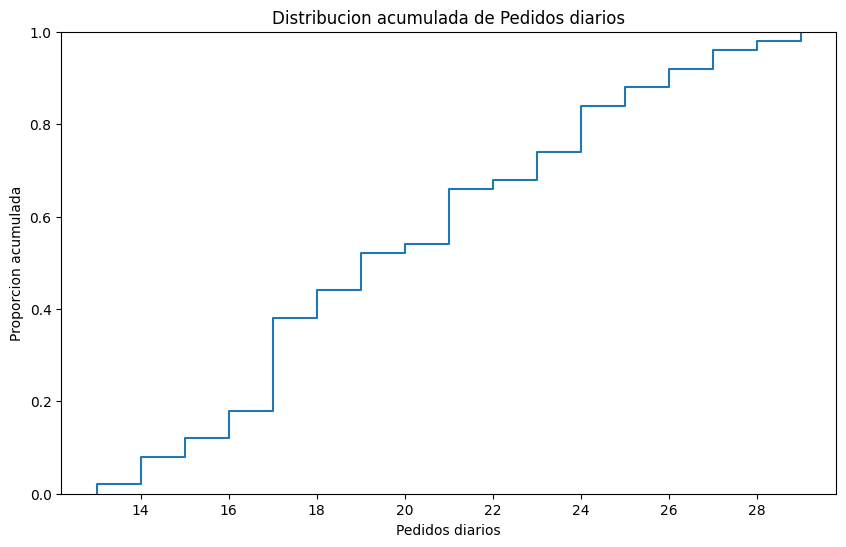

In [12]:
# 4. Grafico de distribucion acumulada (CDF) para Pedidos diarios
plt.figure(figsize=(10,6))
sns.ecdfplot(data['Pedidos_diarios']) # Grafico de distribucion acumulada
plt.title('Distribucion acumulada de Pedidos diarios')
plt.xlabel('Pedidos diarios')
plt.ylabel('Proporcion acumulada')
plt.show()

### **Puntos claves aqui:**

- Para cada valor en el eje X, el valor en el eje Y indica el porcentaje de días en los que los pedidos diarios fueron menores o iguales a ese valor.

- Por ejemplo, si en X=20 la Y es 0.5, significa que el 50% de los días hubo 20 pedidos diarios o menos.

- La curva siempre sube y termina en 1 (o 100%), porque al final todos los datos están acumulados.

---

# **Parte 2: Análisis de Distribución (4 puntos)**

### **1.	Ajusta una distribución discreta (p. ej., Poisson) al número de pedidos diarios. ¿Qué parámetro λ obtienes? Justifica tu respuesta (1 punto)**


In [13]:
# El parametro λ de la Poisson es la media de los pedidos diarios
lambda_poisson = data['Pedidos_diarios'].mean()

print(f"El parametro λ estimado para la distribucion Poisson es: {lambda_poisson:.2f}")

# Probabilidad de recibir exactamente k pedidos en un día
k = 20 # Esto se puede cambiar para calcular la probabilidad de recibir un numero diferente de pedidos

prob_k = poisson.pmf(k, lambda_poisson) # .pmf es la funcion de masa de probabilidad para la distribucion Poisson

print(f"La probabilidad de recibir exactamente {k} pedidos en un dia es: {prob_k*100:.3f}%")

El parametro λ estimado para la distribucion Poisson es: 20.06
La probabilidad de recibir exactamente 20 pedidos en un dia es: 8.883%


**Justificacion:**

- La distribución Poisson es ideal para modelar el numero de pedidos diarios porque se trata de un conteo de eventos que ocurren de manera independiente en un periodo fijo (cada dia). 

- El parametro λ representa el promedio de pedidos diarios, y al ajustarlo a nuestros datos, podemos describir y predecir el comportamiento tipico de los pedidos en la empresa.

- En una prueba, hemos vistoque hay un 8% de probabilidades de recibir exactamente 20 pedidos en un dia

---

### **2.	Ajusta una distribución continua (p. ej., Normal) al tiempo promedio de entrega. ¿Qué valores de μ y σ se obtienen? Justifica si es apropiado usar la normal. (1 punto)**

In [14]:
# Ajuste de la dist. normal: obtiene media (m) y desviacion estándar (de)
m, de = norm.fit(data['Tiempo_promedio_entrega (min)'])

print(f"Media (μ): {m:.2f}")
print(f"Desviacion estandar (σ): {de:.2f}")

Media (μ): 32.04
Desviacion estandar (σ): 3.95


**Justificacion:**

Al invetsigar sobre este concepto, he averiguado que usar la distribución normal es apropiado si los datos de tiempo promedio de entrega estan distribuidos de forma aproximadamente simatrica y no presentan valores extremos muy alejados (outliers)... en este caso es apropiado porque los datos de tiempo, o sea, los Dias, van de manera simetrica, es decir, 1,2,3,4,5,6,7... etc.

---

### **3.	Representa gráficamente la función de densidad de probabilidad (PDF) para una de las variables. (1 punto)**

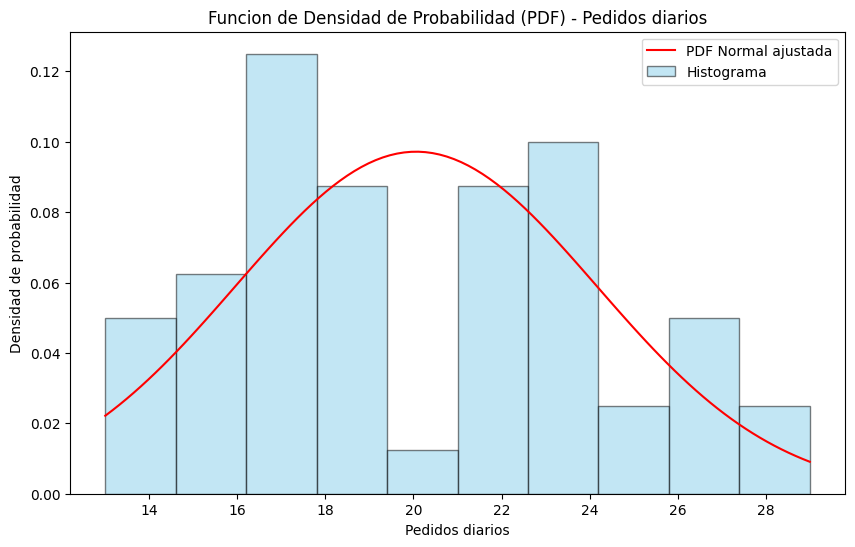

In [15]:
# He elegido la variable "Pedidos diarios" para graficar la funcion de densidad de probabilidad (PDF) porque es una variable 
# numerica continua que representa la cantidad de pedidos realizados en un dia, lo cual es relevante para el analisis de la distribucion de pedidos.

# Ajustamos la distribucion normal a los datos de pedidos diarios
m, de = norm.fit(data['Pedidos_diarios'])

# Creamos el rango de valores para el eje X
x = np.linspace(data['Pedidos_diarios'].min(), data['Pedidos_diarios'].max(), 100)

# Calculamos la PDF usando los parametros ajustados
pdf = norm.pdf(x, m, de)

plt.figure(figsize=(10,6))
plt.plot(x, pdf, color='red', label='PDF Normal ajustada')
plt.hist(data['Pedidos_diarios'], bins=10, density=True, alpha=0.5, color='skyblue', edgecolor='black', label='Histograma')
plt.title('Funcion de Densidad de Probabilidad (PDF) - Pedidos diarios')
plt.xlabel('Pedidos diarios')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.show()

### **4.	Representa y analiza la función de distribución acumulada (CDF) para la variable Tiempo promedio entrega. (1 punto)**

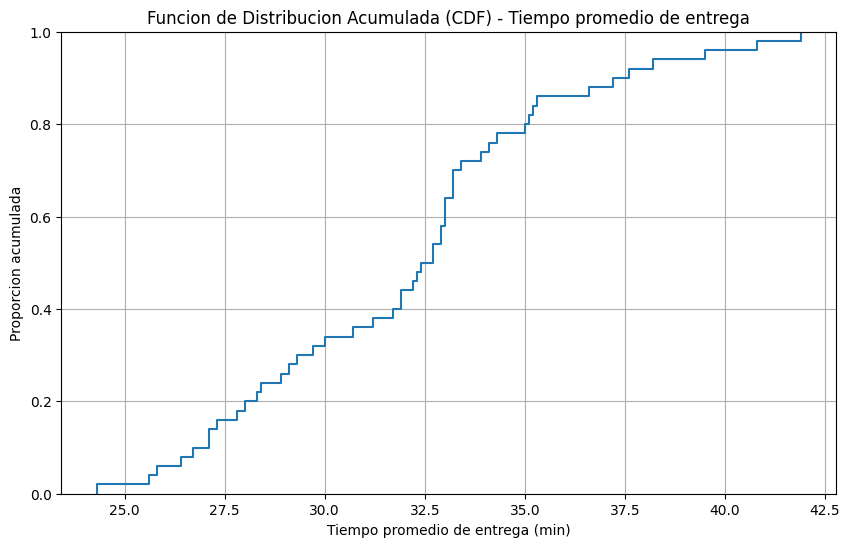

In [16]:
# Distribucion acumulada (CDF) para la variable Tiempo promedio entrega

plt.figure(figsize=(10,6))
sns.ecdfplot(data['Tiempo_promedio_entrega (min)'])
plt.grid(True)
plt.title('Funcion de Distribucion Acumulada (CDF) - Tiempo promedio de entrega')
plt.xlabel('Tiempo promedio de entrega (min)')
plt.ylabel('Proporcion acumulada')
plt.show()

### **Análisis:**

- La curva sube de manera continua desde 0 hasta 1, lo que indica que todos los datos están incluidos.

- Aproximadamente el 50% de las entregas se realizan en menos de 32 minutos (donde la curva cruza Y=0.5).

- La mayoría de los tiempos de entrega están entre 28 y 38 minutos, ya que la pendiente es más pronunciada en ese rango.

- Hay pocos valores extremos: casi no hay entregas menores a 25 minutos ni mayores a 42 minutos.

---

# **Parte 3: Inferencias y Predicciones (4 puntos)**

### **1.	Según la CDF (función de distribución acumulada), ¿cuál es la probabilidad de que una entrega tarde menos de 32 minutos? (1 punto)**

In [17]:
probabilidad = (data['Tiempo_promedio_entrega (min)'] < 32).mean()
print(f"La probabilidad de que una entrega tarde menos de 32 minutos es aproximadamente: {probabilidad*100:.0f}%")

La probabilidad de que una entrega tarde menos de 32 minutos es aproximadamente: 44%


### **Y efectivamente, anteriormente he notado que casi el 50% de las entregas se hacen en menos de `32 minutos`**

---

### **2.	Según la distribución ajustada, ¿cuál es la probabilidad de recibir más de 25 pedidos en un día? (1 punto)**

In [18]:
# P(X > 25) = 1 - P(X <= 25)
probabilidad = 1 - poisson.cdf(25, lambda_poisson) # lambda_poisson es el parametro de la distribucion Poisson (ya lo hemos calculado antes)
print(f"La probabilidad de recibir mas de 25 pedidos en un dia es aproximadamente: {probabilidad*100:.2f}%")

La probabilidad de recibir mas de 25 pedidos en un dia es aproximadamente: 11.49%


---

### **3.	Interpreta el comportamiento de la empresa a partir de los modelos ajustados. ¿Qué conclusiones se pueden obtener? (1 punto)**

A partir de los modelos ajustados se pueden obtener las siguientes conclusiones sobre el comportamiento de la empresa:

- **Pedidos diarios:**  
  El numero de `pedidos diarios` sigue aproximadamente una distribucion Poisson, lo que indica que los pedidos ocurren de manera aleatoria pero con una tasa promedio constante... Lo de ser aleatorio lo entiendo porque se nos dijo que estos datos son ficticios de una empresa que en realidad no existe.

- **Tiempo promedio de entrega:**  
  `El tiempo` promedio de entrega `se ajusta bien` a una distribucion normal, lo que sugiere que la mayoria de las entregas se realizan en torno a un valor central (la media), con pocas entregas muy rapidas o muy lentas. Esto refleja un proceso de entrega estable y controlado.

- **Relacion entre variables:**  
  `La correlacion` entre el numero de pedidos y el tiempo de entrega `es baja` (alrededor de 22%), lo que indica que un aumento en los pedidos diarios no necesariamente implica un aumento significativo en el tiempo de entrega. La empresa parece manejar eficientemente la variabilidad en la demanda.

- **Consistencia operativa:**  
  `La dispersion` de los tiempos de entrega `es baja`, lo que muestra que la empresa mantiene un `servicio consistente`, sin grandes demoras ni entregas excesivamente rapidas.

**En resumen:**  
La empresa presenta un proceso de pedidos y entregas estable, predecible y eficiente, con poca variabilidad y `sin indicios de saturacion` operativa bajo las condiciones actuales.

---

### **4.	Propón una predicción: si el número de pedidos aumenta un 20%, ¿qué se esperaría que suceda con el tiempo promedio de entrega? Justifica con base en tus datos. (1 punto)**

Yo digo que si el numero de pedidos aumenta un 20%, **se esperaria que el tiempo promedio de entrega aumente ligeramente**, pero no de forma significativa.

**Justificacion:**
- `Segun el analisis de correlacion`, la relacion entre el numero de pedidos y el tiempo promedio de entrega es baja (`correlacion = 0.22 o 22%`). Esto indica que, historicamente, un aumento en los pedidos `no ha provocado un gran aumento en el tiempo de entrega`.

- La empresa ha mostrado `consistencia operativa` y capacidad para manejar la variabilidad en la demanda `sin afectar mucho` los tiempos de entrega.

- Sin embargo, `si el aumento de pedidos supera la capacidad operativa`, podria empezar a observarse un `incremento mayor` en los tiempos de entrega. Pero, con base en los datos actuales, el impacto sería **pequeño y manejable**.

**En resumen:**  
`Con un 20% más de pedidos`, el tiempo promedio de entrega `podria aumentar levemente`, pero la empresa probablemente mantendria un `servicio eficiente y consistente`, como ha demostrado en los datos analizados.

# **Conclusion**

Me ha encantado explorar las diferentes pautas que se nos ha planteado en este parcial... solo tengo una sugerencia: ojala que para el proximo sean datos reales, ya que asi podemos practicar en casos reales con interpretaciones mas fuertes.

Pero dejando eso de lado, para mi fue un placer haber concluido con el proyecto... siempre abierto a nuevas oportunidades y practicas.

<div style="display: flex; justify-content: center; align-items: center; height: 300px;">
    <div style="background-color: #28a745; color: white; width: 600px; height: 300px; border-radius: 30px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2); font-size: 64px; font-weight: bold; text-align: center; display: flex; justify-content: center; align-items: center;">
        FIN
        <p style="position: absolute; bottom: 15px; font-size: 14px; color: #ddd;">Jose Carlos Fernandez</p>
    </div>
</div>